""" PROBLEM TSTAEMENT """
The problem — fraud hides in millions of transactions and humans cannot catch it manually.
The challenge — fraud is so rare that a lazy model would just ignore it entirely and still look accurate on paper.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score,
                             roc_curve,
                             precision_recall_curve,
                             average_precision_score)
import time
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import os

# Check if running inside Google Colab
if 'google.colab' in str(get_ipython()):
    print("Running on Google Colab. Mounting Drive...")
    from google.colab import drive
    drive.mount('/content/drive')

    # Loading from Colab
    df = pd.read_csv('/content/drive/MyDrive/creditcard.csv')

else:
    print("Running locally. Looking for local dataset...")
    df = pd.read_csv('creditcard.csv')

Running on Google Colab. Mounting Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Getting Data Shape & Head
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (284807, 31)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# Auditting data

print("=" * 50)
print("BASIC INFO")
print("=" * 50)
print(f"Total Transactions:  {len(df):,}")
print(f"Total Features:      {df.shape[1]}")
print(f"Missing Values:      {df.isnull().sum().sum()}")
print(f"Duplicate Rows:      {df.duplicated().sum()}")

print("\n" + "=" * 50)
print("CLASS DISTRIBUTION")
print("=" * 50)
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]
print(f"Legitimate (0):  {len(legit):,}  ({len(legit)/len(df)*100:.2f}%)")
print(f"Fraudulent  (1): {len(fraud):,}   ({len(fraud)/len(df)*100:.2f}%)")

print("\n" + "=" * 50)
print("DATA TYPES")
print("=" * 50)
print(df.dtypes)

BASIC INFO
Total Transactions:  284,807
Total Features:      31
Missing Values:      0
Duplicate Rows:      1081

CLASS DISTRIBUTION
Legitimate (0):  284,315  (99.83%)
Fraudulent  (1): 492   (0.17%)

DATA TYPES
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [ ]:
# Show first 5 Frauds

df[df['Class'] == 1].head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1
623,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1
4920,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1
6108,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1
6329,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1


In [ ]:
# Removing Duplicates

before = len(df)
df = df.drop_duplicates()
after = len(df)

print(f"Rows before: {before:,}")
print(f"Rows after:  {after:,}")
print(f"Duplicates removed: {before - after:,}")

Rows before: 284,807
Rows after:  283,726
Duplicates removed: 1,081


In [ ]:
# Feature Engineering

# --- 1. Convert Time to Hour of Day ---
# Time is in seconds from the first transaction (48hr window)
# We convert to hour of day to capture time-of-day fraud patterns
df['Hour'] = (df['Time'] / 3600).astype(int) % 24

# --- 2. Transaction Amount Bands ---
# Grouping amounts into business-meaningful buckets
def amount_band(amount):
    if amount <= 10:
        return 'Micro (≤$10)'
    elif amount <= 100:
        return 'Small ($10–$100)'
    elif amount <= 1000:
        return 'Medium ($100–$1K)'
    else:
        return 'Large (>$1K)'

df['Amount_Band'] = df['Amount'].apply(amount_band)

# --- 3. Log-transform Amount ---
# Amount is heavily right-skewed. Log transform brings it
# closer to normal distribution for better ML performance
df['Log_Amount'] = np.log1p(df['Amount'])

print("✅ New features created:")
print(f"  - Hour          : Hour of day (0–23)")
print(f"  - Amount_Band   : Categorical transaction size")
print(f"  - Log_Amount    : Log-transformed amount")
print()
print(df[['Time', 'Hour', 'Amount', 'Log_Amount', 'Amount_Band']].head(10))

✅ New features created:
  - Hour          : Hour of day (0–23)
  - Amount_Band   : Categorical transaction size
  - Log_Amount    : Log-transformed amount

   Time  Hour  Amount  Log_Amount        Amount_Band
0   0.0     0  149.62    5.014760  Medium ($100–$1K)
1   0.0     0    2.69    1.305626       Micro (≤$10)
2   1.0     0  378.66    5.939276  Medium ($100–$1K)
3   1.0     0  123.50    4.824306  Medium ($100–$1K)
4   2.0     0   69.99    4.262539   Small ($10–$100)
5   2.0     0    3.67    1.541159       Micro (≤$10)
6   4.0     0    4.99    1.790091       Micro (≤$10)
7   7.0     0   40.80    3.732896   Small ($10–$100)
8   7.0     0   93.20    4.545420   Small ($10–$100)
9   9.0     0    3.68    1.543298       Micro (≤$10)


In [ ]:
# Scaling

scaler = StandardScaler()

df['Scaled_Amount'] = scaler.fit_transform(df[['Amount']])
df['Scaled_Time']   = scaler.fit_transform(df[['Time']])

# Drop original Amount and Time — replaced by scaled versions
df_model = df.drop(columns=['Time', 'Amount', 'Amount_Band'])

print("✅ Scaling complete")
print(f"Scaled_Amount — Mean: {df['Scaled_Amount'].mean():.4f}, Std: {df['Scaled_Amount'].std():.4f}")
print(f"Scaled_Time   — Mean: {df['Scaled_Time'].mean():.4f},   Std: {df['Scaled_Time'].std():.4f}")
print()
print("Model-ready columns:", df_model.shape[1])

✅ Scaling complete
Scaled_Amount — Mean: -0.0000, Std: 1.0000
Scaled_Time   — Mean: 0.0000,   Std: 1.0000

Model-ready columns: 33


In [ ]:
#  Train_Test_Split

X = df_model.drop(columns=['Class', 'Log_Amount', 'Hour'])
y = df_model['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserves fraud ratio in both splits
)

print("✅ Train/Test Split Complete")
print(f"\nTraining Set:   {X_train.shape[0]:,} rows")
print(f"Test Set:       {X_test.shape[0]:,} rows")
print()
print("Fraud in Training Set:", y_train.sum())
print("Fraud in Test Set:    ", y_test.sum())

✅ Train/Test Split Complete

Training Set:   226,980 rows
Test Set:       56,746 rows

Fraud in Training Set: 378
Fraud in Test Set:     95


In [ ]:
# Verify fraud ratio is consistent across both splits
print(f"Training fraud ratio: {y_train.sum() / len(y_train) * 100:.4f}%")
print(f"Test fraud ratio:     {y_test.sum() / len(y_test) * 100:.4f}%")

Training fraud ratio: 0.1665%
Test fraud ratio:     0.1674%


In [ ]:

# Summary of results obtained

print(f"  Total transactions (after dedup) : {len(df):,}")
print(f"  Legitimate transactions           : {len(df[df['Class']==0]):,}")
print(f"  Fraudulent transactions           : {len(df[df['Class']==1]):,}")
print(f"  Features going into model         : {X_train.shape[1]}")
print(f"  Training rows                     : {X_train.shape[0]:,}")
print(f"  Test rows                         : {X_test.shape[0]:,}")
print(f"  Missing values remaining          : {df_model.isnull().sum().sum()}")
print(f"  New engineered features           : Hour, Log_Amount, Amount_Band")

  Total transactions (after dedup) : 283,726
  Legitimate transactions           : 283,253
  Fraudulent transactions           : 473
  Features going into model         : 30
  Training rows                     : 226,980
  Test rows                         : 56,746
  Missing values remaining          : 0
  New engineered features           : Hour, Log_Amount, Amount_Band


In [ ]:
# EDA

# Set visual style for all charts
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
colors = ['#2ecc71', '#e74c3c']  # green = legitimate, red = fraud

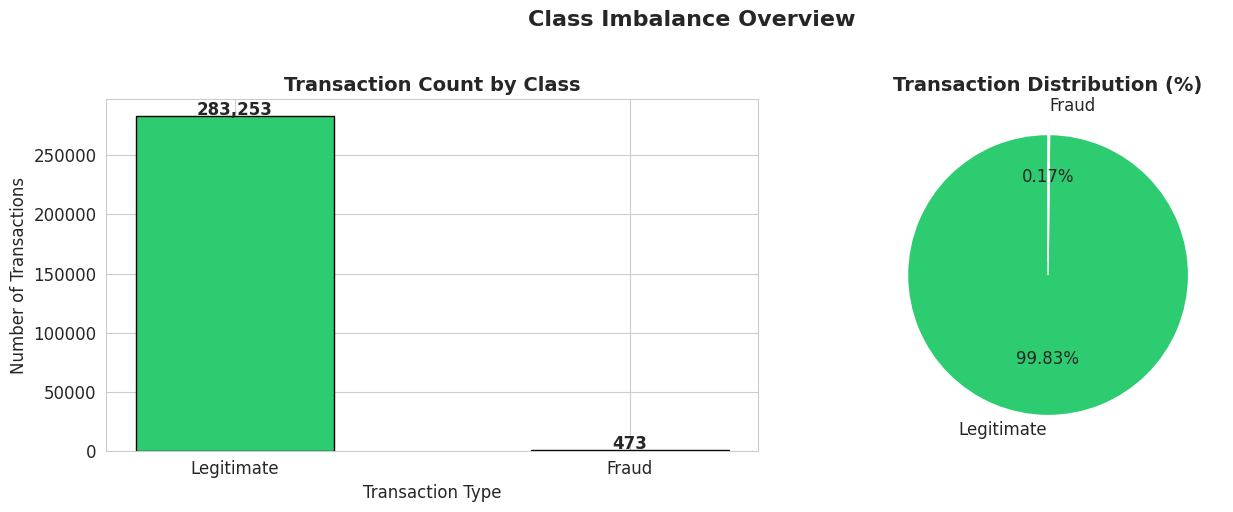

In [ ]:
# Class Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Chart 1: Count of transactions ---
counts = df['Class'].value_counts()
axes[0].bar(['Legitimate', 'Fraud'], counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Transaction Count by Class', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_xlabel('Transaction Type')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# --- Chart 2: Percentage breakdown ---
percentages = df['Class'].value_counts(normalize=True) * 100
axes[1].pie(percentages.values,
            labels=['Legitimate', 'Fraud'],
            colors=colors,
            autopct='%1.2f%%',
            startangle=90,
            explode=(0, 0.1))
axes[1].set_title('Transaction Distribution (%)', fontsize=14, fontweight='bold')

plt.suptitle('Class Imbalance Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

(0.0, 2500.0)

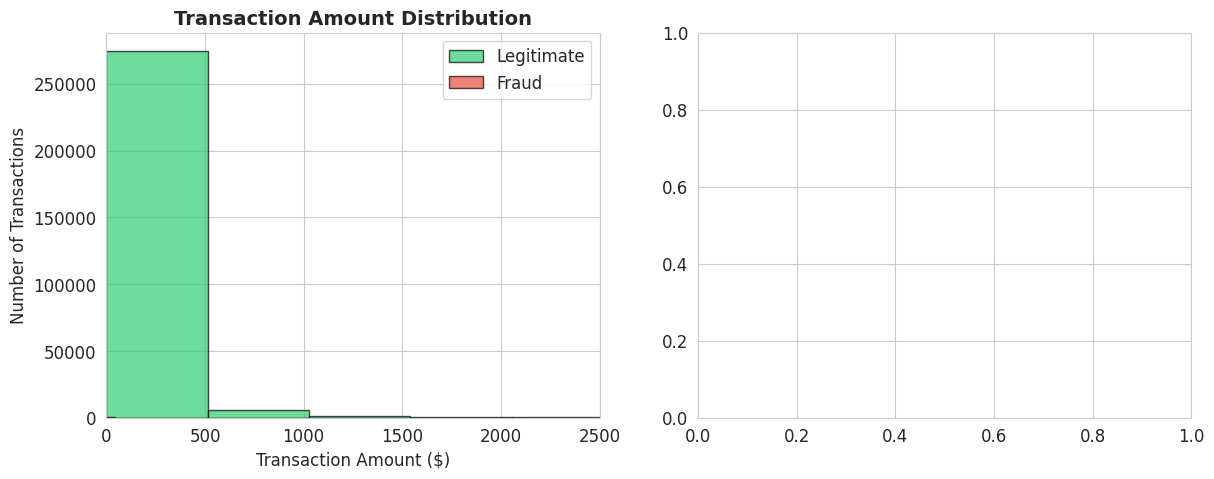

In [ ]:
#Transaction & Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Chart 1: Amount distribution by class ---
axes[0].hist(df[df['Class']==0]['Amount'], bins=50,
             color='#2ecc71', alpha=0.7, label='Legitimate', edgecolor='black')
axes[0].hist(df[df['Class']==1]['Amount'], bins=50,
             color='#e74c3c', alpha=0.7, label='Fraud', edgecolor='black')
axes[0].set_title('Transaction Amount Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Transaction Amount ($)')
axes[0].set_ylabel('Number of Transactions')
axes[0].legend()
axes[0].set_xlim(0, 2500)

# ---

In [ ]:
# Doube checking since 2nd chart looks empty

print(f"Average Legitimate Amount: ${df[df['Class']==0]['Amount'].mean():.2f}")
print(f"Average Fraud Amount:      ${df[df['Class']==1]['Amount'].mean():.2f}")

Average Legitimate Amount: $88.41
Average Fraud Amount:      $123.87


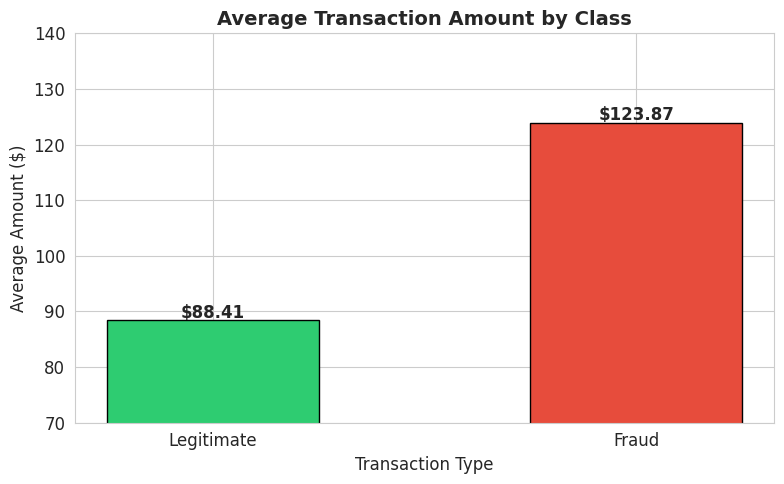

In [ ]:
# Fix 2nd chart y-axis to show difference clearly
fig, ax = plt.subplots(figsize=(8, 5))

avg_amounts = df.groupby('Class')['Amount'].mean()
ax.bar(['Legitimate', 'Fraud'], avg_amounts.values,
       color=colors, edgecolor='black', width=0.5)
ax.set_title('Average Transaction Amount by Class', fontsize=14, fontweight='bold')
ax.set_xlabel('Transaction Type')
ax.set_ylabel('Average Amount ($)')
ax.set_ylim(70, 140)  # zoom in to show difference clearly

for i, v in enumerate(avg_amounts.values):
    ax.text(i, v + 0.5, f'${v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('amount_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

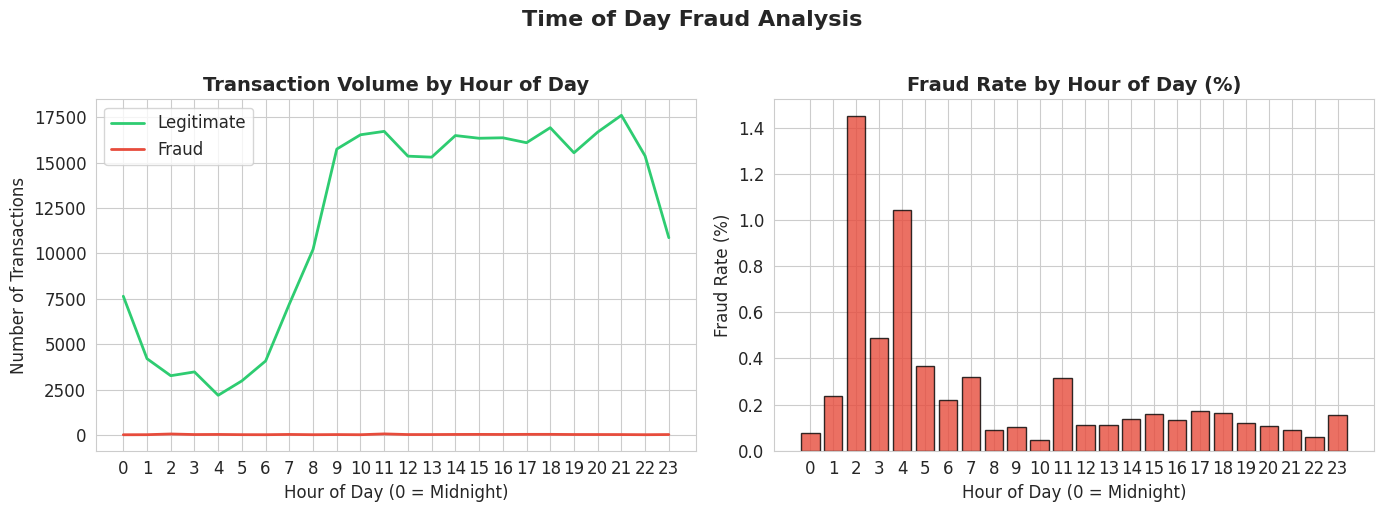

Top 5 Highest Fraud Rate Hours:
Hour
2    1.451028
4    1.043557
3    0.487525
5    0.368139
7    0.317987
Name: Class, dtype: float64


In [ ]:
# Fraud By Hour of the Day

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Chart 1: Transaction volume by hour ---
legit_by_hour = df[df['Class']==0].groupby('Hour')['Class'].count()
fraud_by_hour = df[df['Class']==1].groupby('Hour')['Class'].count()

axes[0].plot(legit_by_hour.index, legit_by_hour.values,
             color='#2ecc71', label='Legitimate', linewidth=2)
axes[0].plot(fraud_by_hour.index, fraud_by_hour.values,
             color='#e74c3c', label='Fraud', linewidth=2)
axes[0].set_title('Transaction Volume by Hour of Day', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hour of Day (0 = Midnight)')
axes[0].set_ylabel('Number of Transactions')
axes[0].legend()
axes[0].set_xticks(range(0, 24))

# --- Chart 2: Fraud rate by hour ---
fraud_rate = df.groupby('Hour')['Class'].mean() * 100

axes[1].bar(fraud_rate.index, fraud_rate.values,
            color='#e74c3c', edgecolor='black', alpha=0.8)
axes[1].set_title('Fraud Rate by Hour of Day (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hour of Day (0 = Midnight)')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_xticks(range(0, 24))

plt.suptitle('Time of Day Fraud Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fraud_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

# Print peak fraud hours
print("Top 5 Highest Fraud Rate Hours:")
print(fraud_rate.sort_values(ascending=False).head())

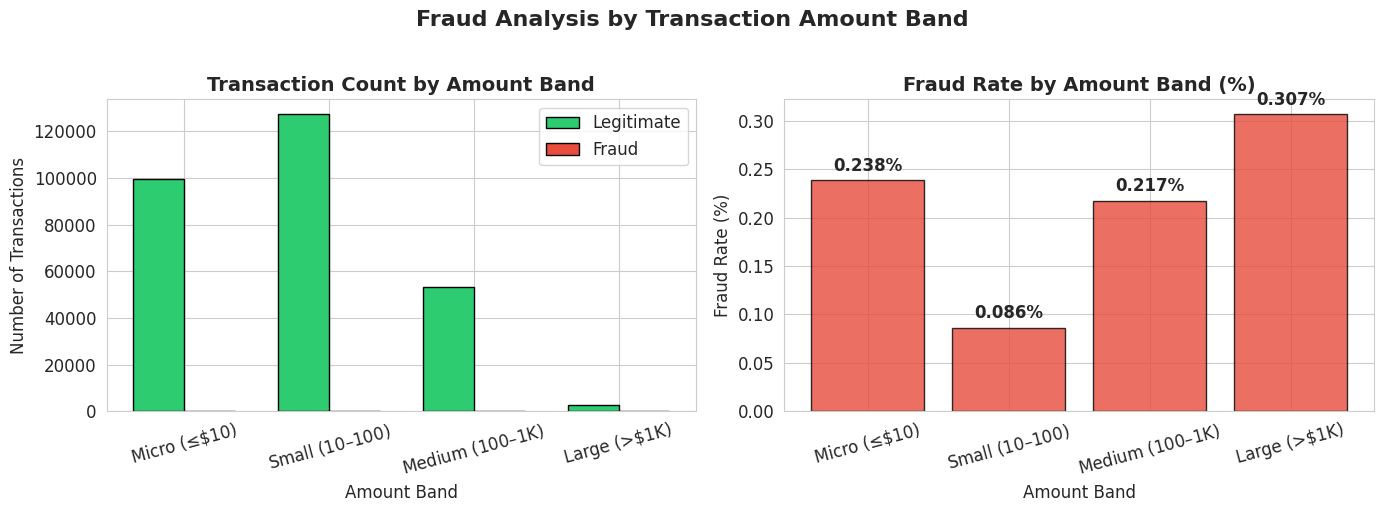

Fraud Rate by Amount Band:
  Micro (≤$10)              → 0.238% (238 fraud out of 99,821 transactions)
  Small ($10–$100)          → 0.086% (110 fraud out of 127,506 transactions)
  Medium ($100–$1K)         → 0.217% (116 fraud out of 53,464 transactions)
  Large (>$1K)              → 0.307% (9 fraud out of 2,935 transactions)


In [ ]:

# Fraud By Amount Band

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Define correct order for amount bands
band_order = ['Micro (≤$10)', 'Small ($10–$100)',
              'Medium ($100–$1K)', 'Large (>$1K)']

# --- Chart 1: Transaction count by amount band ---
legit_bands = df[df['Class']==0]['Amount_Band'].value_counts()
fraud_bands = df[df['Class']==1]['Amount_Band'].value_counts()

x = range(len(band_order))
width = 0.35

axes[0].bar([i - width/2 for i in x],
            [legit_bands.get(b, 0) for b in band_order],
            width, color='#2ecc71', label='Legitimate', edgecolor='black')
axes[0].bar([i + width/2 for i in x],
            [fraud_bands.get(b, 0) for b in band_order],
            width, color='#e74c3c', label='Fraud', edgecolor='black')
axes[0].set_title('Transaction Count by Amount Band', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Amount Band')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_xticks(x)
axes[0].set_xticklabels(band_order, rotation=15)
axes[0].legend()

# --- Chart 2: Fraud rate by amount band ---
fraud_rate_band = df.groupby('Amount_Band')['Class'].mean() * 100
fraud_rate_band = fraud_rate_band.reindex(band_order)

axes[1].bar(band_order, fraud_rate_band.values,
            color='#e74c3c', edgecolor='black', alpha=0.8)
axes[1].set_title('Fraud Rate by Amount Band (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Amount Band')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_xticklabels(band_order, rotation=15)
for i, v in enumerate(fraud_rate_band.values):
    axes[1].text(i, v + 0.01, f'{v:.3f}%', ha='center', fontweight='bold')

plt.suptitle('Fraud Analysis by Transaction Amount Band',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fraud_by_amount_band.png', dpi=150, bbox_inches='tight')
plt.show()

# Print fraud rate by band
print("Fraud Rate by Amount Band:")
for band in band_order:
    rate = df[df['Amount_Band']==band]['Class'].mean() * 100
    count = len(df[df['Amount_Band']==band])
    fraud_count = df[df['Amount_Band']==band]['Class'].sum()
    print(f"  {band:<25} → {rate:.3f}% ({fraud_count} fraud out of {count:,} transactions)")

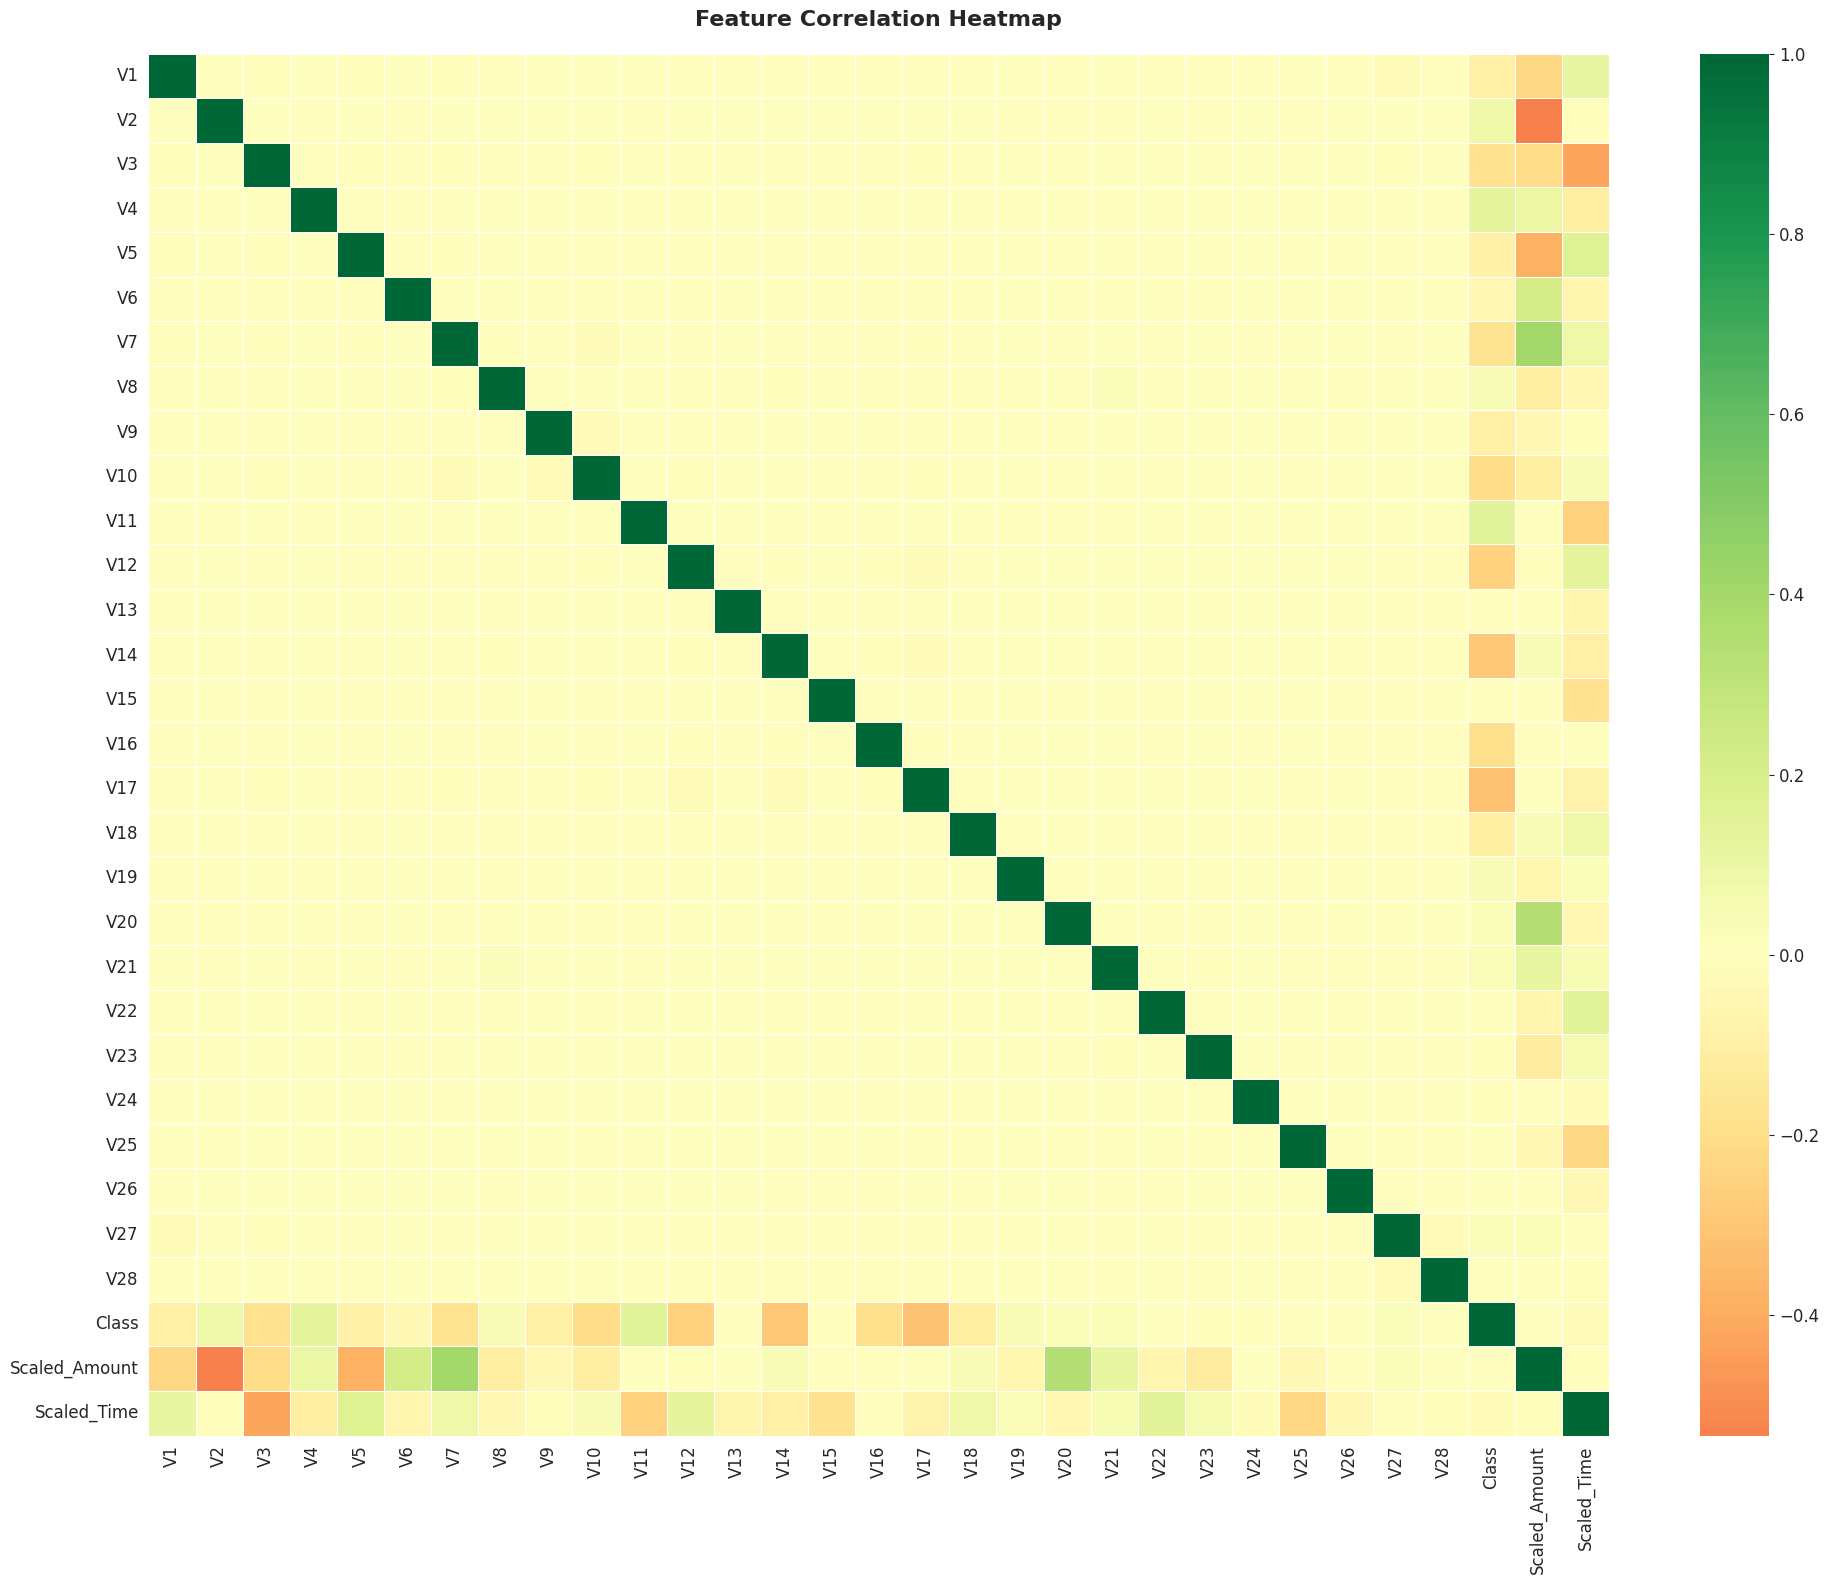

Top 10 Features Most Correlated with Fraud (Class):
V17    0.313498
V14    0.293375
V12    0.250711
V10    0.206971
V16    0.187186
V3     0.182322
V7     0.172347
V11    0.149067
V4     0.129326
V18    0.105340
Name: Class, dtype: float64


In [ ]:
# Correlation Heatmap

fig, ax = plt.subplots(figsize=(20, 16))

# Calculate correlation matrix
corr_matrix = df_model.drop(columns=['Log_Amount',
                                      'Hour']).corr()

# Plot heatmap
sns.heatmap(corr_matrix,
            cmap='RdYlGn',
            center=0,
            annot=False,
            linewidths=0.5,
            ax=ax)

ax.set_title('Feature Correlation Heatmap',
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top features correlated with fraud
print("Top 10 Features Most Correlated with Fraud (Class):")
corr_with_class = corr_matrix['Class'].drop('Class').abs().sort_values(ascending=False)
print(corr_with_class.head(10))

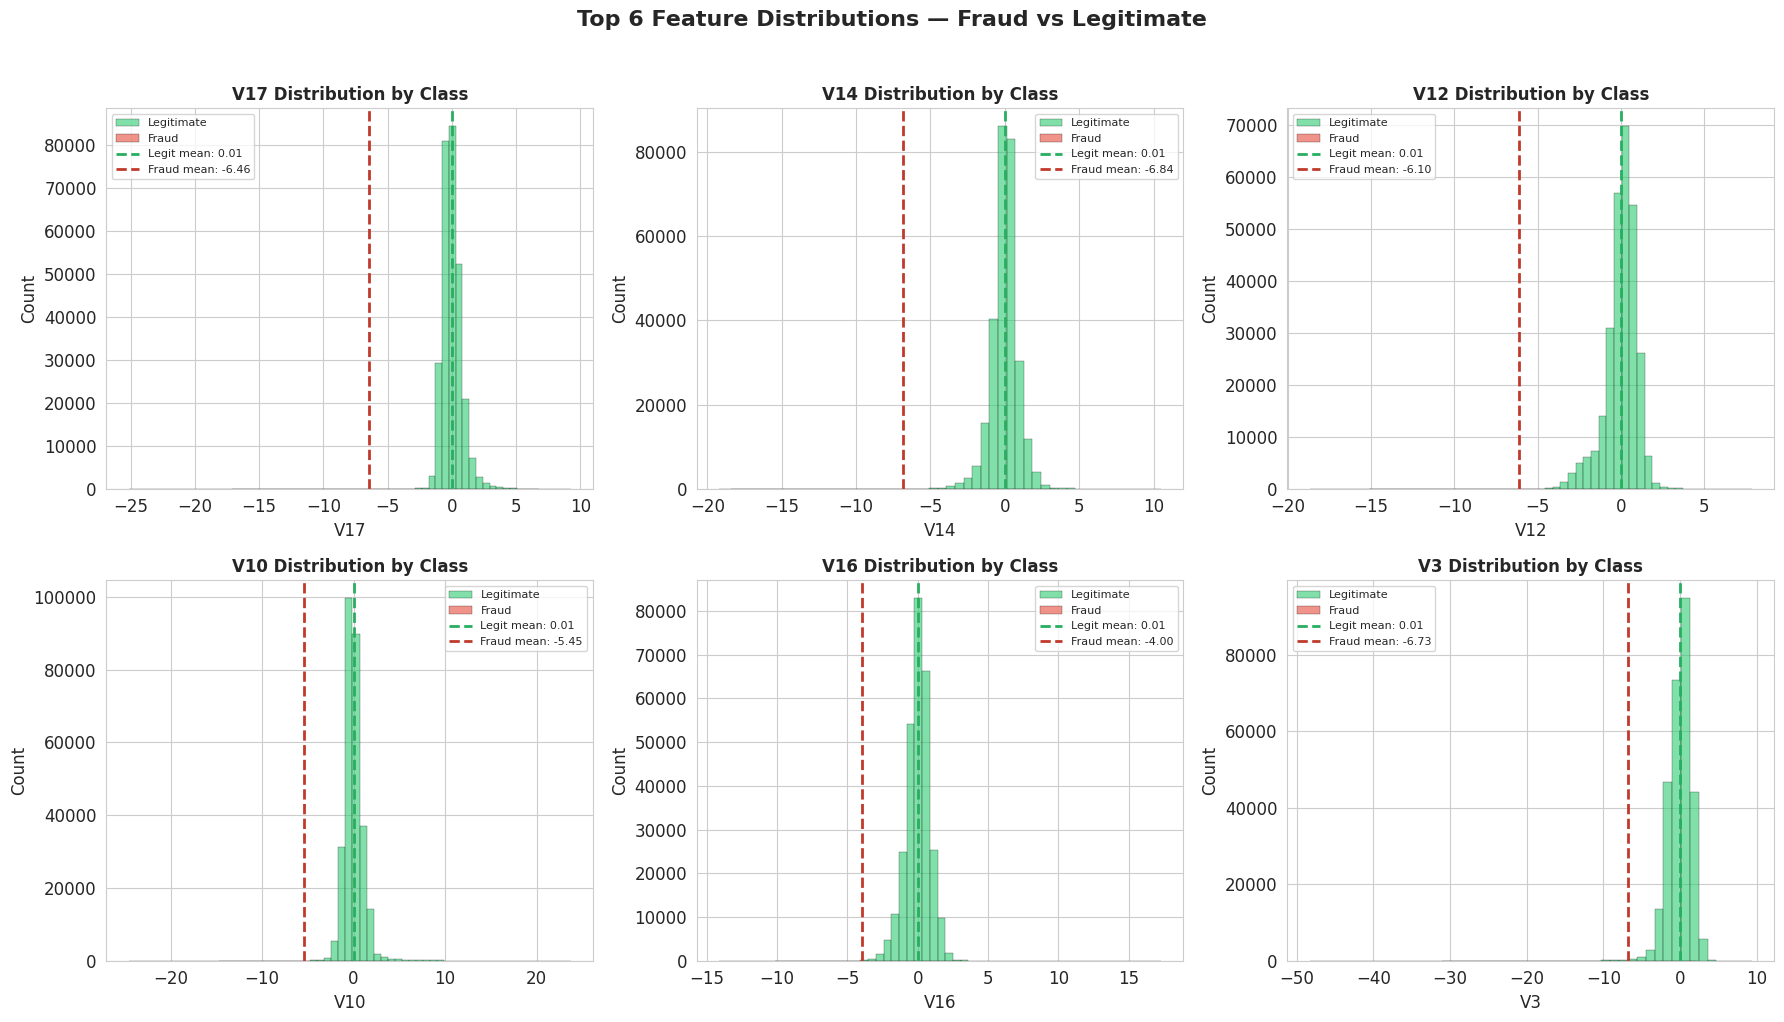

Feature Mean Comparison — Fraud vs Legitimate:
Feature      Legit Mean   Fraud Mean   Difference
--------------------------------------------------
V17              0.0110      -6.4633      -6.4742
V14              0.0117      -6.8359      -6.8476
V12              0.0095      -6.1033      -6.1127
V10              0.0077      -5.4533      -5.4609
V16              0.0078      -4.0010      -4.0088
V3               0.0129      -6.7296      -6.7425


In [ ]:
# Top Fraud Features Distribution

# Top 6 features most correlated with fraud
top_features = ['V17', 'V14', 'V12', 'V10', 'V16', 'V3']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    # Plot legitimate
    axes[i].hist(df[df['Class']==0][feature],
                 bins=50, color='#2ecc71',
                 alpha=0.6, label='Legitimate',
                 edgecolor='black', linewidth=0.3)
    # Plot fraud
    axes[i].hist(df[df['Class']==1][feature],
                 bins=50, color='#e74c3c',
                 alpha=0.6, label='Fraud',
                 edgecolor='black', linewidth=0.3)

    axes[i].set_title(f'{feature} Distribution by Class',
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')
    axes[i].legend()

    # Add mean lines
    legit_mean = df[df['Class']==0][feature].mean()
    fraud_mean = df[df['Class']==1][feature].mean()
    axes[i].axvline(legit_mean, color='#27ae60',
                    linestyle='--', linewidth=2,
                    label=f'Legit mean: {legit_mean:.2f}')
    axes[i].axvline(fraud_mean, color='#c0392b',
                    linestyle='--', linewidth=2,
                    label=f'Fraud mean: {fraud_mean:.2f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Top 6 Feature Distributions — Fraud vs Legitimate',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('top_features_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Print mean differences
print("Feature Mean Comparison — Fraud vs Legitimate:")
print(f"{'Feature':<10} {'Legit Mean':>12} {'Fraud Mean':>12} {'Difference':>12}")
print("-" * 50)
for feature in top_features:
    legit_mean = df[df['Class']==0][feature].mean()
    fraud_mean = df[df['Class']==1][feature].mean()
    diff = fraud_mean - legit_mean
    print(f"{feature:<10} {legit_mean:>12.4f} {fraud_mean:>12.4f} {diff:>12.4f}")

In [ ]:
# Summary for EDA

print("""
KEY FINDINGS:
─────────────────────────────────────────────────────────────
1. CLASS IMBALANCE
   → 99.83% legitimate vs 0.17% fraud
   → Confirms need for SMOTE in Phase 3

2. TRANSACTION AMOUNTS
   → Avg legitimate: $88.41 | Avg fraud: $123.87
   → Fraudsters blend in — amount alone cannot detect fraud

3. TIME OF DAY
   → Fraud peaks at 2am (1.45% rate — 8x dataset average)
   → Overnight hours are highest risk window

4. AMOUNT BANDS
   → Micro transactions (≤$10): 0.238% fraud rate
   → Card testing behaviour confirmed in micro band
   → Large transactions (>$1K): highest fraud rate at 0.307%

5. TOP FRAUD FEATURES
   → V17, V14, V12, V10, V16, V3 most correlated with fraud
   → All top features shift 4–7 units negative in fraud cases
   → Clear feature separation confirms ML will be effective

─────────────────────────────────────────────────────────────
CHARTS SAVED:
   → class_distribution.png
   → amount_distribution.png
   → amount_comparison.png
   → fraud_by_hour.png
   → fraud_by_amount_band.png
   → correlation_heatmap.png
   → top_features_distribution.png
─────────────────────────────────────────────────────────────
""")


KEY FINDINGS:
─────────────────────────────────────────────────────────────
1. CLASS IMBALANCE
   → 99.83% legitimate vs 0.17% fraud
   → Confirms need for SMOTE in Phase 3

2. TRANSACTION AMOUNTS
   → Avg legitimate: $88.41 | Avg fraud: $123.87
   → Fraudsters blend in — amount alone cannot detect fraud

3. TIME OF DAY
   → Fraud peaks at 2am (1.45% rate — 8x dataset average)
   → Overnight hours are highest risk window

4. AMOUNT BANDS
   → Micro transactions (≤$10): 0.238% fraud rate
   → Card testing behaviour confirmed in micro band
   → Large transactions (>$1K): highest fraud rate at 0.307%

5. TOP FRAUD FEATURES
   → V17, V14, V12, V10, V16, V3 most correlated with fraud
   → All top features shift 4–7 units negative in fraud cases
   → Clear feature separation confirms ML will be effective

─────────────────────────────────────────────────────────────
CHARTS SAVED:
   → class_distribution.png
   → amount_distribution.png
   → amount_comparison.png
   → fraud_by_hour.png
   → 

In [ ]:
!pip install xgboost --quiet

In [ ]:
# Apply Smote

print("Before SMOTE:")
print(f"  Legitimate: {sum(y_train == 0):,}")
print(f"  Fraud:      {sum(y_train == 1):,}")
print(f"  Ratio:      {sum(y_train == 1)/len(y_train)*100:.4f}%")

# Apply SMOTE to training set only — NEVER on test set
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(f"  Legitimate: {sum(y_train_sm == 0):,}")
print(f"  Fraud:      {sum(y_train_sm == 1):,}")
print(f"  Ratio:      {sum(y_train_sm == 1)/len(y_train_sm)*100:.4f}%")
print(f"\n  Training rows before: {len(X_train):,}")
print(f"  Training rows after:  {len(X_train_sm):,}")
print(f"  Synthetic fraud cases created: {sum(y_train_sm == 1) - sum(y_train == 1):,}")

print("\n✅ SMOTE Applied Successfully")

Before SMOTE:
  Legitimate: 226,602
  Fraud:      378
  Ratio:      0.1665%

After SMOTE:
  Legitimate: 226,602
  Fraud:      226,602
  Ratio:      50.0000%

  Training rows before: 226,980
  Training rows after:  453,204
  Synthetic fraud cases created: 226,224

✅ SMOTE Applied Successfully


✅ Training Complete — 5.13 seconds

       LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56651
       Fraud       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746

ROC-AUC Score:  0.9619
PR-AUC Score:   0.6768


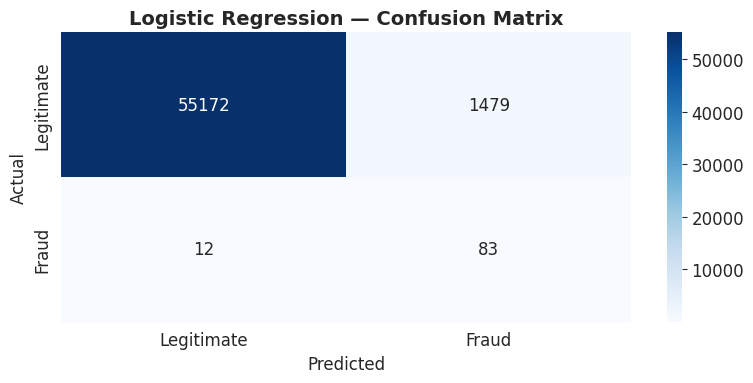

In [ ]:
# Logistic Regression

start = time.time()

# Train model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_sm, y_train_sm)

# Predict on test set
lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

end = time.time()
print(f"✅ Training Complete — {end - start:.2f} seconds")

# Results
print("\n" + "=" * 55)
print("       LOGISTIC REGRESSION RESULTS")
print("=" * 55)
print(classification_report(y_test, lr_pred,
                            target_names=['Legitimate', 'Fraud']))

print(f"ROC-AUC Score:  {roc_auc_score(y_test, lr_prob):.4f}")
print(f"PR-AUC Score:   {average_precision_score(y_test, lr_prob):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(8, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Logistic Regression — Confusion Matrix',
          fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('lr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

(Optimised version — 50 trees)
✅ Training Complete — 163.00 seconds

         RANDOM FOREST RESULTS
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.54      0.79      0.64        95

    accuracy                           1.00     56746
   macro avg       0.77      0.89      0.82     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC Score:  0.9796
PR-AUC Score:   0.7689


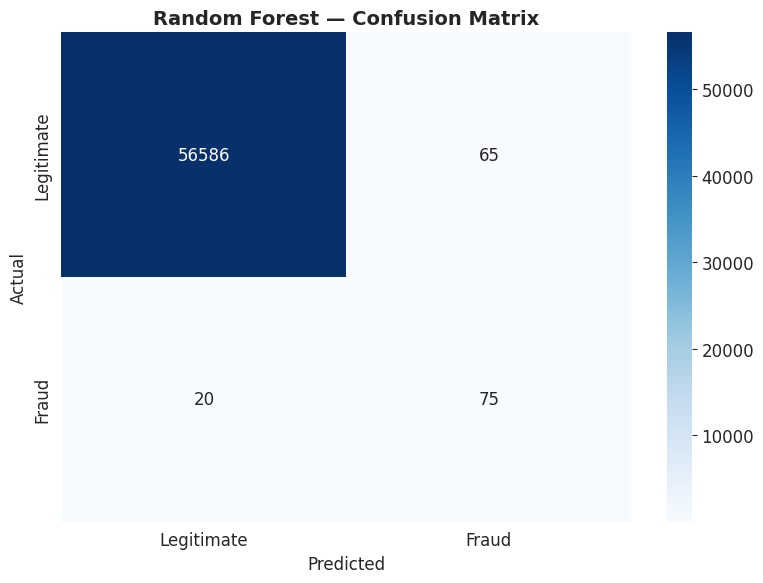

In [ ]:
# Random Forest

print("(Optimised version — 50 trees)")
start = time.time()

# Reduced to 50 trees for Colab performance
# n_jobs=-1 uses all available CPU cores
rf_model = RandomForestClassifier(n_estimators=50,
                                   max_depth=10,
                                   random_state=42,
                                   n_jobs=-1)
rf_model.fit(X_train_sm, y_train_sm)

# Predict on test set
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

end = time.time()
print(f"✅ Training Complete — {end - start:.2f} seconds")

# Results
print("\n" + "=" * 55)
print("         RANDOM FOREST RESULTS")
print("=" * 55)
print(classification_report(y_test, rf_pred,
                            target_names=['Legitimate', 'Fraud']))

print(f"ROC-AUC Score:  {roc_auc_score(y_test, rf_prob):.4f}")
print(f"PR-AUC Score:   {average_precision_score(y_test, rf_prob):.4f}")

# Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Random Forest — Confusion Matrix',
          fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Note: n_estimators reduced to 50 and max_depth capped at 10
# for Colab computational efficiency. In a production environment
# with dedicated infrastructure, 100-500 trees would be standard.

✅ Training Complete — 11.54 seconds

           XGBOOST RESULTS
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.40      0.82      0.54        95

    accuracy                           1.00     56746
   macro avg       0.70      0.91      0.77     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC Score:  0.9742
PR-AUC Score:   0.8007


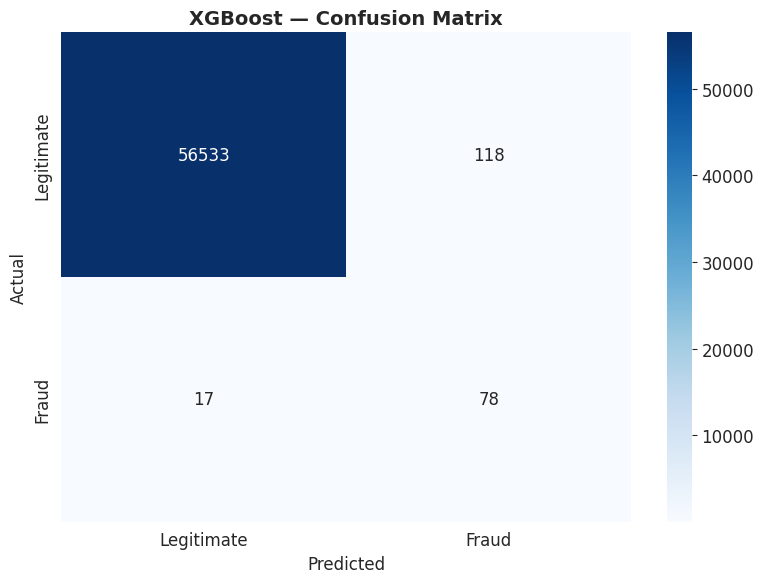

In [ ]:
# XGBoost

start = time.time()

# Train model
xgb_model = XGBClassifier(n_estimators=100,
                           max_depth=6,
                           learning_rate=0.1,
                           subsample=0.8,
                           colsample_bytree=0.8,
                           scale_pos_weight=1,
                           random_state=42,
                           eval_metric='logloss',
                           verbosity=0)

xgb_model.fit(X_train_sm, y_train_sm)

# Predict on test set
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

end = time.time()
print(f"✅ Training Complete — {end - start:.2f} seconds")

# Results
print("\n" + "=" * 55)
print("           XGBOOST RESULTS")
print("=" * 55)
print(classification_report(y_test, xgb_pred,
                            target_names=['Legitimate', 'Fraud']))

print(f"ROC-AUC Score:  {roc_auc_score(y_test, xgb_prob):.4f}")
print(f"PR-AUC Score:   {average_precision_score(y_test, xgb_prob):.4f}")

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('XGBoost — Confusion Matrix',
          fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('xgb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#  Saving Trained Models to G-Drive

import joblib
import os

# Create models folder in Google Drive
model_path = '/content/drive/MyDrive/Fraud_Detection_Project/Models/'
os.makedirs(model_path, exist_ok=True)

# Save all three models
joblib.dump(lr_model,  model_path + 'lr_model.pkl')
joblib.dump(rf_model,  model_path + 'rf_model.pkl')
joblib.dump(xgb_model, model_path + 'xgb_model.pkl')

print("✅ All models saved to Google Drive")
print(f"📁 Location: {model_path}")

✅ All models saved to Google Drive
📁 Location: /content/drive/MyDrive/Fraud_Detection_Project/Models/


In [ ]:
# Verify models saved
files = os.listdir(model_path)
print("Models in Drive:")
for f in files:
    print(f"  ✅ {f}")

Models in Drive:
  ✅ lr_model.pkl
  ✅ rf_model.pkl
  ✅ xgb_model.pkl


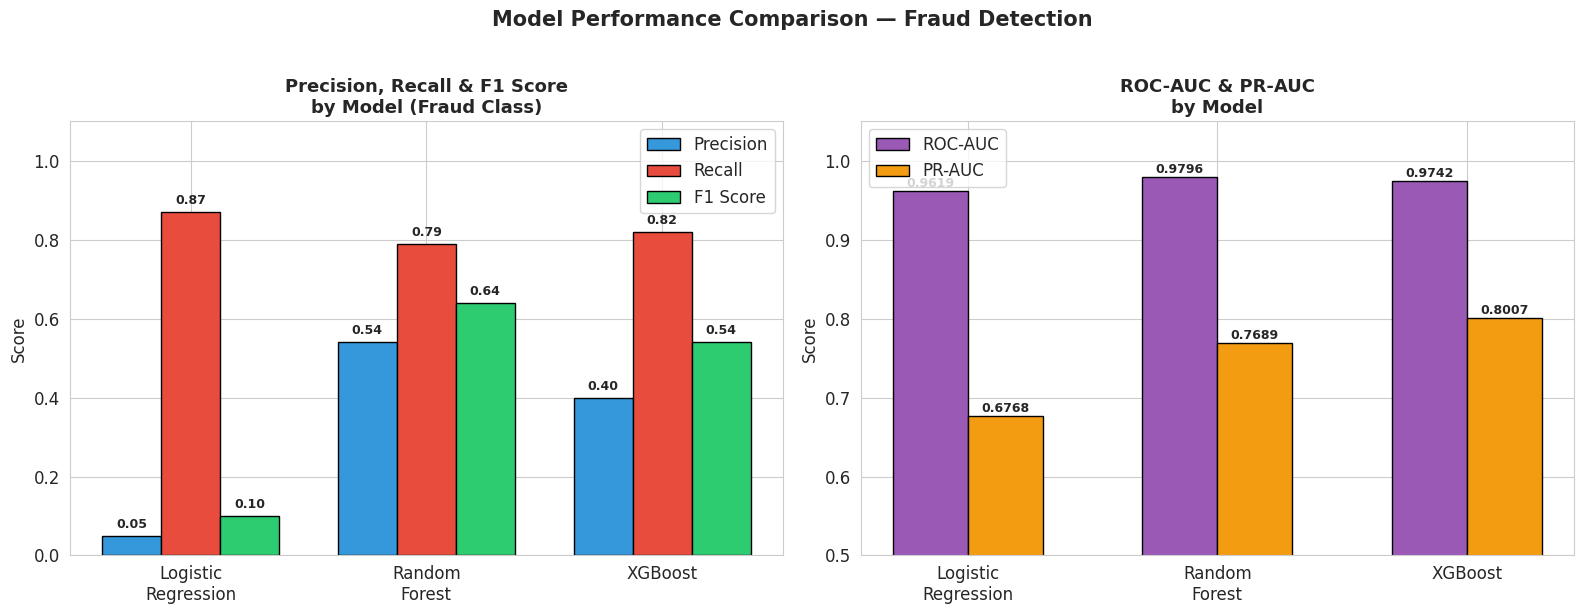

In [ ]:
# Model Comparison Chart

# Model results summary
models = ['Logistic\nRegression', 'Random\nForest', 'XGBoost']

metrics = {
    'Precision': [0.05, 0.54, 0.40],
    'Recall':    [0.87, 0.79, 0.82],
    'F1 Score':  [0.10, 0.64, 0.54],
    'ROC-AUC':   [0.9619, 0.9796, 0.9742],
    'PR-AUC':    [0.6768, 0.7689, 0.8007]
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Chart 1: Precision, Recall, F1 comparison ---
x = range(len(models))
width = 0.25

axes[0].bar([i - width for i in x], metrics['Precision'],
            width, label='Precision', color='#3498db', edgecolor='black')
axes[0].bar([i for i in x], metrics['Recall'],
            width, label='Recall',    color='#e74c3c', edgecolor='black')
axes[0].bar([i + width for i in x], metrics['F1 Score'],
            width, label='F1 Score',  color='#2ecc71', edgecolor='black')

axes[0].set_title('Precision, Recall & F1 Score\nby Model (Fraud Class)',
                   fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.1)
axes[0].legend()

# Add value labels
for i, (p, r, f) in enumerate(zip(metrics['Precision'],
                                    metrics['Recall'],
                                    metrics['F1 Score'])):
    axes[0].text(i - width, p + 0.02, f'{p:.2f}',
                 ha='center', fontsize=9, fontweight='bold')
    axes[0].text(i,          r + 0.02, f'{r:.2f}',
                 ha='center', fontsize=9, fontweight='bold')
    axes[0].text(i + width,  f + 0.02, f'{f:.2f}',
                 ha='center', fontsize=9, fontweight='bold')

# --- Chart 2: ROC-AUC and PR-AUC comparison ---
x2 = range(len(models))
width2 = 0.3

axes[1].bar([i - width2/2 for i in x2], metrics['ROC-AUC'],
            width2, label='ROC-AUC', color='#9b59b6', edgecolor='black')
axes[1].bar([i + width2/2 for i in x2], metrics['PR-AUC'],
            width2, label='PR-AUC',  color='#f39c12', edgecolor='black')

axes[1].set_title('ROC-AUC & PR-AUC\nby Model',
                   fontsize=13, fontweight='bold')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(models)
axes[1].set_ylabel('Score')
axes[1].set_ylim(0.5, 1.05)
axes[1].legend()

# Add value labels
for i, (r, p) in enumerate(zip(metrics['ROC-AUC'], metrics['PR-AUC'])):
    axes[1].text(i - width2/2, r + 0.005, f'{r:.4f}',
                 ha='center', fontsize=9, fontweight='bold')
    axes[1].text(i + width2/2, p + 0.005, f'{p:.4f}',
                 ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Performance Comparison — Fraud Detection',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


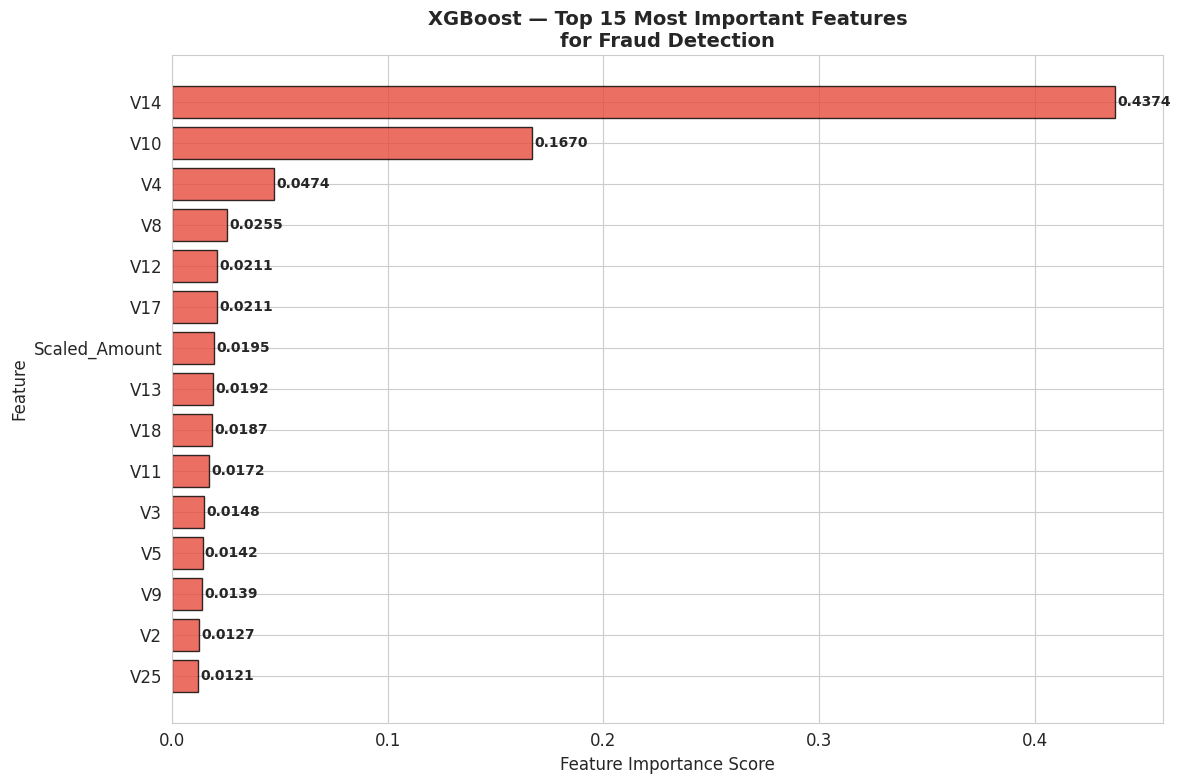

Top 10 Most Important Features:
----------------------------------------
  V14                  0.4374
  V10                  0.1670
  V4                   0.0474
  V8                   0.0255
  V12                  0.0211
  V17                  0.0211
  Scaled_Amount        0.0195
  V13                  0.0192
  V18                  0.0187
  V11                  0.0172


In [ ]:
# Feature Importance - XG Boost

# Extract feature importance from XGBoost
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(feature_importance['Feature'][::-1],
               feature_importance['Importance'][::-1],
               color='#e74c3c', edgecolor='black', alpha=0.8)

# Add value labels
for bar, val in zip(bars, feature_importance['Importance'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

ax.set_title('XGBoost — Top 15 Most Important Features\nfor Fraud Detection',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Feature Importance Score')
ax.set_ylabel('Feature')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top 10
print("Top 10 Most Important Features:")
print("-" * 40)
for i, row in feature_importance.head(10).iterrows():
    print(f"  {row['Feature']:<20} {row['Importance']:.4f}")

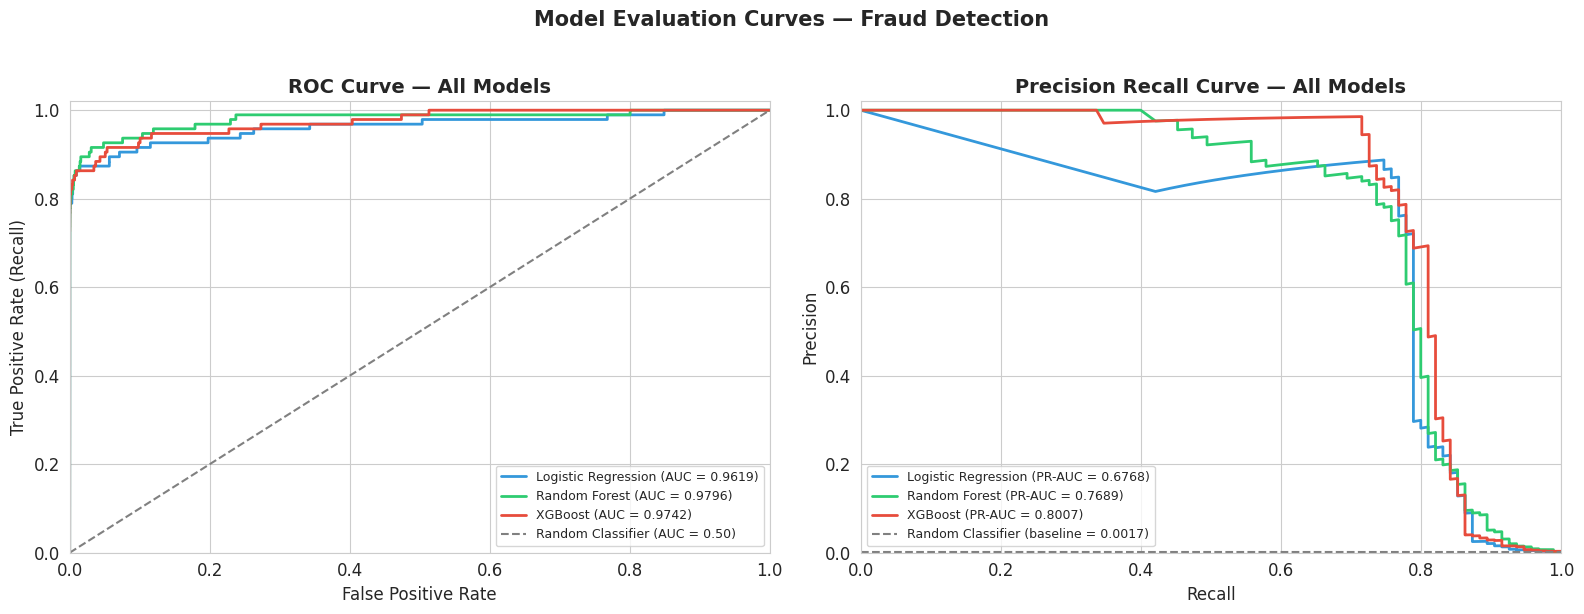

✅ ROC and Precision Recall curves saved


In [ ]:
# ROC Curve & Precision Recall Curve

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── ROC CURVES ──────────────────────────────────────────────
# Logistic Regression
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
# Random Forest
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
# XGBoost
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

axes[0].plot(lr_fpr,  lr_tpr,
             label=f'Logistic Regression (AUC = 0.9619)',
             color='#3498db', linewidth=2)
axes[0].plot(rf_fpr,  rf_tpr,
             label=f'Random Forest (AUC = 0.9796)',
             color='#2ecc71', linewidth=2)
axes[0].plot(xgb_fpr, xgb_tpr,
             label=f'XGBoost (AUC = 0.9742)',
             color='#e74c3c', linewidth=2)
axes[0].plot([0, 1], [0, 1],
             linestyle='--', color='gray',
             label='Random Classifier (AUC = 0.50)')

axes[0].set_title('ROC Curve — All Models',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].legend(fontsize=9)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])

# ── PRECISION RECALL CURVES ─────────────────────────────────
# Logistic Regression
lr_prec, lr_rec, _ = precision_recall_curve(y_test, lr_prob)
# Random Forest
rf_prec, rf_rec, _ = precision_recall_curve(y_test, rf_prob)
# XGBoost
xgb_prec, xgb_rec, _ = precision_recall_curve(y_test, xgb_prob)

axes[1].plot(lr_rec,  lr_prec,
             label=f'Logistic Regression (PR-AUC = 0.6768)',
             color='#3498db', linewidth=2)
axes[1].plot(rf_rec,  rf_prec,
             label=f'Random Forest (PR-AUC = 0.7689)',
             color='#2ecc71', linewidth=2)
axes[1].plot(xgb_rec, xgb_prec,
             label=f'XGBoost (PR-AUC = 0.8007)',
             color='#e74c3c', linewidth=2)

# Baseline — random classifier on imbalanced data
baseline = y_test.sum() / len(y_test)
axes[1].axhline(y=baseline, linestyle='--',
                color='gray',
                label=f'Random Classifier (baseline = {baseline:.4f})')

axes[1].set_title('Precision Recall Curve — All Models',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.suptitle('Model Evaluation Curves — Fraud Detection',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ ROC and Precision Recall curves saved")

In [ ]:
# Saving Charts to G-Drive

import shutil
import os

# Create charts folder in Drive
charts_path = '/content/drive/MyDrive/Fraud_Detection_Project/Charts/'
os.makedirs(charts_path, exist_ok=True)

# All charts to save
all_charts = [
    # Phase 2 charts
    'class_distribution.png',
    'amount_comparison.png',
    'fraud_by_hour.png',
    'fraud_by_amount_band.png',
    'correlation_heatmap.png',
    'top_features_distribution.png',
    # Phase 3 charts
    'lr_confusion_matrix.png',
    'rf_confusion_matrix.png',
    'xgb_confusion_matrix.png',
    'model_comparison.png',
    'feature_importance.png',
    'roc_pr_curves.png'
]

for chart in all_charts:
    if os.path.exists(chart):
        shutil.copy(chart, charts_path + chart)
        print(f"✅ Saved: {chart}")
    else:
        print(f"⚠️ Not found: {chart}")

print(f"\n✅ All charts saved to Google Drive")
print(f"📁 Location: {charts_path}")

✅ Saved: class_distribution.png
✅ Saved: amount_comparison.png
✅ Saved: fraud_by_hour.png
✅ Saved: fraud_by_amount_band.png
✅ Saved: correlation_heatmap.png
✅ Saved: top_features_distribution.png
✅ Saved: lr_confusion_matrix.png
✅ Saved: rf_confusion_matrix.png
✅ Saved: xgb_confusion_matrix.png
✅ Saved: model_comparison.png
✅ Saved: feature_importance.png
✅ Saved: roc_pr_curves.png

✅ All charts saved to Google Drive
📁 Location: /content/drive/MyDrive/Fraud_Detection_Project/Charts/


In [ ]:
print('''# Summary

MODELS TRAINED:
─────────────────────────────────────────────────────────────
1. LOGISTIC REGRESSION (Baseline)
   → Precision: 0.05  Recall: 0.87  F1: 0.10
   → ROC-AUC: 0.9619  PR-AUC: 0.6768
   → Finding: High Recall but too many false alarms

2. RANDOM FOREST (Ensemble)
   → Precision: 0.54  Recall: 0.79  F1: 0.64
   → ROC-AUC: 0.9796  PR-AUC: 0.7689
   → Finding: Best Precision — fewest false alarms

3. XGBOOST (Recommended)
   → Precision: 0.40  Recall: 0.82  F1: 0.54
   → ROC-AUC: 0.9742  PR-AUC: 0.8007
   → Finding: Best PR-AUC — strongest overall performer

─────────────────────────────────────────────────────────────
KEY DECISIONS:
   → SMOTE applied to training set only
   → Stratified train/test split maintained
   → Models saved permanently to Google Drive

─────────────────────────────────────────────────────────────
TOP FRAUD FEATURES (XGBoost):
   → V14 (0.4374) — dominant signal
   → V10 (0.1670) — strong second
   → V4, V8, V12, V17 — supporting signals

─────────────────────────────────────────────────────────────
RECOMMENDATION:
   → Deploy XGBoost as primary fraud detection model
   → Monitor V14 and V10 as priority fraud signals
   → Flag overnight transactions for enhanced review
─────────────────────────────────────────────────────────────
''')

# Summary

MODELS TRAINED:
─────────────────────────────────────────────────────────────
1. LOGISTIC REGRESSION (Baseline)
   → Precision: 0.05  Recall: 0.87  F1: 0.10
   → ROC-AUC: 0.9619  PR-AUC: 0.6768
   → Finding: High Recall but too many false alarms

2. RANDOM FOREST (Ensemble)
   → Precision: 0.54  Recall: 0.79  F1: 0.64
   → ROC-AUC: 0.9796  PR-AUC: 0.7689
   → Finding: Best Precision — fewest false alarms

3. XGBOOST (Recommended)
   → Precision: 0.40  Recall: 0.82  F1: 0.54
   → ROC-AUC: 0.9742  PR-AUC: 0.8007
   → Finding: Best PR-AUC — strongest overall performer

─────────────────────────────────────────────────────────────
KEY DECISIONS:
   → SMOTE applied to training set only
   → Stratified train/test split maintained
   → Models saved permanently to Google Drive

─────────────────────────────────────────────────────────────
TOP FRAUD FEATURES (XGBoost):
   → V14 (0.4374) — dominant signal
   → V10 (0.1670) — strong second
   → V4, V8, V12, V17 — supporting signals

──

In [ ]:
# ============================================================
# SAVE CLEANED DATASET TO GOOGLE DRIVE
# ============================================================

import os

# Create Data folder in Drive
data_path = '/content/drive/MyDrive/Fraud_Detection_Project/Data/'
os.makedirs(data_path, exist_ok=True)

# Save cleaned dataset
df.to_csv(data_path + 'creditcard_cleaned.csv', index=False)

print("✅ Cleaned dataset saved to Google Drive")
print(f"📁 Location: {data_path}")
print(f"Shape: {df.shape}")

✅ Cleaned dataset saved to Google Drive
📁 Location: /content/drive/MyDrive/Fraud_Detection_Project/Data/
Shape: (283726, 36)


In [ ]:
# ============================================================
# CREATE REQUIREMENTS.TXT
# ============================================================

requirements = """pandas
numpy
matplotlib
seaborn
scikit-learn
xgboost
imbalanced-learn"""

with open('/content/drive/MyDrive/Fraud_Detection_Project/requirements.txt', 'w') as f:
    f.write(requirements)

print("✅ requirements.txt created and saved to Google Drive")

✅ requirements.txt created and saved to Google Drive


In [ ]:
# Verify contents
with open('/content/drive/MyDrive/Fraud_Detection_Project/requirements.txt', 'r') as f:
    print(f.read())

pandas
numpy
matplotlib
seaborn
scikit-learn
xgboost
imbalanced-learn


In [ ]:
# ============================================================
# CREATE POWER BI OPTIMISED DATASET
# ============================================================

# Select only columns needed for dashboard
powerbi_df = df[['Time', 'Amount', 'Class',
                  'Hour', 'Amount_Band',
                  'Log_Amount']].copy()

# Add readable class label
powerbi_df['Transaction_Type'] = powerbi_df['Class'].map({
    0: 'Legitimate',
    1: 'Fraud'
})

print(f"Original dataset: {df.shape}")
print(f"Power BI dataset: {powerbi_df.shape}")
print(f"\nColumns: {powerbi_df.columns.tolist()}")

# Save to Drive
powerbi_df.to_csv(
    '/content/drive/MyDrive/Fraud_Detection_Project/creditcard_powerbi.csv',
    index=False
)

print("\n✅ Power BI optimised dataset saved to Drive")

Original dataset: (283726, 36)
Power BI dataset: (283726, 7)

Columns: ['Time', 'Amount', 'Class', 'Hour', 'Amount_Band', 'Log_Amount', 'Transaction_Type']

✅ Power BI optimised dataset saved to Drive
